# Einfluss meteorologischer Bedingungen auf die Photovoltaikerzeugung in Deutschland

**Projektdokumentation und reproduzierbare Analyse**

**Forschungsfrage:** Unter welchen meteorologischen Bedingungen ist die auf die
installierte Leistung normierte Photovoltaikerzeugung in Deutschland am höchsten?

**These:** Die höchste normierte Photovoltaikerzeugung tritt bei hoher
Sonneneinstrahlung und moderaten Temperaturen auf. Bei sehr hohen Temperaturen
nimmt die Erzeugung trotz starker Einstrahlung wieder ab.

**Ziel:** Ein stündliches Modell prognostiziert den deutschen PV-Kapazitätsfaktor
und identifiziert Bedingungen mit erhöhtem thermischem Verlust.

Das Notebook verwendet dieselben Funktionen wie die Streamlit-App. Fehlen reale
SMARD-/DWD-Daten, läuft es mit eindeutig markierten synthetischen Demodaten.
Diese sind kein empirischer Befund.

> **Dokumentationsstatus:** Dieses Notebook beschreibt Datenquellen,
> Aufbereitung, Modellvertrag, zentrale Analysen, App-Logik und Grenzen des
> Forschungsprototyps. Es ist die ausführbare technische Dokumentation; die
> Präsentation kann daraus die fachlich wichtigsten Ergebnisse verdichten.

## Leseführung und Zuordnung zur App

| Dokumentationsbereich | Zweck | Entsprechender App-Bereich |
|---|---|---|
| 1–3 | Datenherkunft, Qualität und aufbereitete Merkmale | Über die App |
| 4–5 | Explorative Prüfung der Forschungsfrage | Datenexploration |
| 6 | Training, zeitlicher Test und Modellgüte | Über die App |
| 7 | Berechnung eines meteorologischen Szenarios | Prognose |
| 8 | Modellreaktion auf veränderte Lufttemperatur | Thermischer Effekt |
| 9 | Vergleich mit besonders ertragreichen Beobachtungen | Optimale Bedingungen |
| 10–12 | Implementierungslandkarte, Reproduktion und Grenzen | Projektdokumentation |

**Empfohlene Lesereihenfolge:** Für die fachliche Argumentation sind besonders
die Abschnitte 4, 5, 8 und 12 relevant. Für die technische Nachvollziehbarkeit
sind die Abschnitte 1–3, 6, 7, 10 und 11 maßgeblich.

## 1. Systemüberblick, Datenquellen und Datenstatus

SMARD liefert realisierte Photovoltaikerzeugung und die installierte Leistung.
DWD-Stationsdaten werden deutschlandweit aggregiert. Gespeichert wird in UTC.
Kalendermerkmale werden für die Datenexploration in Europe/Berlin erzeugt,
gehören aber bewusst nicht zu den Eingaben des meteorologischen
Prognosemodells.

### Amtliche Quellen

- [SMARD – Marktdaten](https://www.smard.de/home/downloadcenter/download-marktdaten/):
  realisierte Photovoltaikerzeugung und installierte PV-Leistung
- [DWD – Solarstrahlung](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/solar/)
- [DWD – Temperatur und Feuchte](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/air_temperature/historical/)
- [DWD – Bewölkung](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/cloudiness/historical/)
- [DWD – Wind](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/wind/historical/)

### Datenfluss

```text
SMARD-Erzeugung ─┐
SMARD-Leistung  ─┼─> stündliches UTC-Panel ─> Feature Engineering
DWD-Stationen   ─┘             │                       │
                               ├─> Datenexploration     ├─> zeitliches Training/Test
                               └─> Tabellenvorschau     └─> App-Prognosen
```

Zentrale Artefakte sind `data/raw/download_manifest.json` für die Herkunft,
`data/processed/hourly_pv_weather.csv` für das aufbereitete Panel,
`pv_weather/` für die gemeinsame Logik sowie `app.py` für die Oberfläche.

In [11]:
import json
import platform
from pathlib import Path
import sys
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from pv_weather import (
    MODEL_FEATURES,
    TARGET,
    add_features,
    estimate_module_temperature,
    load_project_data,
    predict_yield,
    train_yield_model,
)
from pv_weather.features import MONOTONIC_CONSTRAINTS

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

data, source = load_project_data(ROOT / "data" / "processed" / "hourly_pv_weather.csv")
IS_DEMO = source.startswith("Synthetische")
print(source)
print(f"{len(data):,} Stunden | {data.timestamp_utc.min()} bis {data.timestamp_utc.max()}")
if IS_DEMO:
    print("ACHTUNG: Alle folgenden Zahlen illustrieren nur den Workflow.")
display(data.head())

Realdaten: C:/Users/morri/PycharmProjects/BigData-Photovoltaikerzeugung/data/processed/hourly_pv_weather.csv
52,608 Stunden | 2020-01-01 00:00:00+00:00 bis 2025-12-31 23:00:00+00:00


,timestamp_utc,temperature_c,relative_humidity_pct,global_radiation_j_cm2,diffuse_radiation_j_cm2,sunshine_duration_min,solar_zenith_angle_deg,cloud_cover_oktas,wind_speed_m_s,installed_pv_capacity_mw,pv_generation_mwh
0,2020-01-01 00:00:00+00:00,1.79375,90.7500,0.0,0.0,0.0,151.053125,5.5625,2.79375,47754.0,0.0
1,2020-01-01 01:00:00+00:00,1.58125,91.0625,0.0,0.0,0.0,146.724375,5.5625,3.00625,47754.0,0.0
2,2020-01-01 02:00:00+00:00,1.35625,91.4375,0.0,0.0,0.0,139.546250,6.1250,3.00625,47754.0,0.0
3,2020-01-01 03:00:00+00:00,1.06250,92.1250,0.0,0.0,0.0,130.913750,5.1250,3.10000,47754.0,0.0
4,2020-01-01 04:00:00+00:00,1.08750,91.2500,0.0,0.0,0.0,121.681250,4.2500,2.85625,47754.0,0.0


### 1.1 Ausführungsumgebung und Herkunftsprotokoll

Die folgende Zelle dokumentiert, mit welcher Python- und Paketversion das
Notebook ausgeführt wurde. Wenn Realdaten über die App oder das Downloadskript
geladen wurden, enthält das Manifest zusätzlich Zeitraum, Quellen,
Stationskennungen, verarbeitete Zeilenzahl und Modellkennzahlen.

In [12]:
environment = pd.DataFrame(
    {
        "Version": {
            "Python": platform.python_version(),
            "pandas": version("pandas"),
            "NumPy": version("numpy"),
            "scikit-learn": version("scikit-learn"),
            "Streamlit": version("streamlit"),
        }
    }
)
display(environment)

manifest_path = ROOT / "data" / "raw" / "download_manifest.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    manifest_summary = {
        "Downloadzeitpunkt (UTC)": manifest.get("downloaded_at_utc"),
        "Zeitraum": f"{manifest.get('start_year')}–{manifest.get('end_year')}",
        "DWD-Stationen": len(manifest.get("dwd_station_ids", [])),
        "DWD-Stations-IDs": ", ".join(manifest.get("dwd_station_ids", [])),
        "Aufbereitete Stunden": manifest.get("processed_rows"),
        "Paneldatei": manifest.get("processed_file"),
    }
    display(pd.Series(manifest_summary, name="Herkunftsprotokoll").to_frame())
else:
    print("Kein Downloadmanifest vorhanden; Datenherkunft über die Quellenangabe oben prüfen.")

,Version
Python,3.12.6
pandas,2.2.0
NumPy,1.26.4
scikit-learn,1.6.1
Streamlit,1.51.0


,Herkunftsprotokoll
Downloadzeitpunkt (UTC),2026-07-26T11:43:51.880132+00:00
Zeitraum,2020–2025
DWD-Stationen,16
DWD-Stations-IDs,"00183, 00662, 00691, 00853, 01684, 02712, 0363..."
Aufbereitete Stunden,52608
Paneldatei,data\processed\hourly_pv_weather.csv


## 2. Datenqualität und Zielvariable

Der stündliche Kapazitätsfaktor ist dimensionslos:

`PV-Erzeugung [MWh] / (installierte PV-Leistung [MW] × 1 h)`

Jahreswerte der installierten Leistung sind eine Näherung, weil der Ausbau
innerhalb des Jahres nicht vollständig abgebildet wird.

Bei der Aufbereitung werden Zeitstempel und Zahlenformate vereinheitlicht,
doppelte UTC-Stunden gemittelt und unplausible Werte als fehlend markiert.
Geprüft werden unter anderem Feuchte (0–100 %), Bewölkung (0–8 Achtel),
Sonnenscheindauer (0–60 Minuten), Sonnenzenit (0–180°), positive installierte
Leistung und eine normierte Erzeugung zwischen 0 und 1,2.

**Wichtig:** Ein Messwert von 0 ist nicht automatisch fehlend. Nullwerte bei
Global- und Diffusstrahlung sowie Sonnenscheindauer sind nachts physikalisch
plausibel und bleiben deshalb im vollständigen Panel erhalten.

In [13]:
hourly = add_features(data)
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "fehlend_n": data.isna().sum(),
    "fehlend_pct": data.isna().mean().mul(100).round(2),
    "eindeutig": data.nunique(),
})
display(quality)
print(f"Doppelte UTC-Stunden: {data['timestamp_utc'].duplicated().sum()}")
print(f"Ungültige Zielwerte: {(~hourly[TARGET].between(0, 1.2) & hourly[TARGET].notna()).sum()}")
display(hourly[["timestamp_utc", "pv_generation_mwh", "installed_pv_capacity_mw", TARGET]].head())

zero_columns = [
    "global_radiation_j_cm2",
    "diffuse_radiation_j_cm2",
    "sunshine_duration_min",
    "pv_generation_mwh",
]
zero_summary = pd.DataFrame(
    {
        "Nullwerte (Stunden)": data[zero_columns].eq(0).sum(),
        "Anteil (%)": data[zero_columns].eq(0).mean().mul(100).round(2),
    }
)
display(zero_summary)

,dtype,fehlend_n,fehlend_pct,eindeutig
timestamp_utc,"datetime64[ns, UTC]",0,0.0,52608
temperature_c,float64,0,0.0,7434
relative_humidity_pct,float64,0,0.0,1941
global_radiation_j_cm2,float64,0,0.0,9549
diffuse_radiation_j_cm2,float64,0,0.0,5235
sunshine_duration_min,float64,0,0.0,2500
solar_zenith_angle_deg,float64,0,0.0,46258
cloud_cover_oktas,float64,2,0.0,349
wind_speed_m_s,float64,0,0.0,2595
installed_pv_capacity_mw,float64,0,0.0,6


Doppelte UTC-Stunden: 0
Ungültige Zielwerte: 0


,timestamp_utc,pv_generation_mwh,installed_pv_capacity_mw,normalized_pv_generation
0,2020-01-01 00:00:00+00:00,0.0,47754.0,0.0
1,2020-01-01 01:00:00+00:00,0.0,47754.0,0.0
2,2020-01-01 02:00:00+00:00,0.0,47754.0,0.0
3,2020-01-01 03:00:00+00:00,0.0,47754.0,0.0
4,2020-01-01 04:00:00+00:00,0.0,47754.0,0.0


,Nullwerte (Stunden),Anteil (%)
global_radiation_j_cm2,22480,42.73
diffuse_radiation_j_cm2,22575,42.91
sunshine_duration_min,24517,46.60
pv_generation_mwh,4226,8.03


### 2.1 Datenwörterbuch des Stundenpanels

| Spalte | Einheit | Bedeutung |
|---|---:|---|
| `timestamp_utc` | UTC | Beginn beziehungsweise Bezug der gemeinsamen Stunde |
| `temperature_c` | °C | deutschlandweit aggregierte Lufttemperatur |
| `relative_humidity_pct` | % | relative Luftfeuchtigkeit |
| `global_radiation_j_cm2` | J/cm² | stündliche Globalstrahlung auf horizontaler Fläche |
| `diffuse_radiation_j_cm2` | J/cm² | diffuser Anteil der stündlichen Strahlung |
| `sunshine_duration_min` | min | Sonnenscheindauer innerhalb der Stunde |
| `solar_zenith_angle_deg` | Grad | Winkel zwischen Sonne und Lot |
| `cloud_cover_oktas` | Achtel | Bewölkung von 0 bis 8 |
| `wind_speed_m_s` | m/s | Windgeschwindigkeit |
| `installed_pv_capacity_mw` | MW | jährlich zugeordnete installierte PV-Leistung |
| `pv_generation_mwh` | MWh | realisierte PV-Energie der Stunde |
| `normalized_pv_generation` | Anteil | Zielvariable aus Erzeugung und Leistung |

Die Tabelle beschreibt die aufbereitete Deutschlandebene. Einzelne
Stationswerte werden nicht im finalen Panel gespeichert.

## 3. Wetteraggregation und Feature Engineering

Das Stundenpanel enthält Global-/Diffusstrahlung, Sonnenscheindauer,
Sonnenzenit, Lufttemperatur, Feuchte, Bewölkung und Wind. Nicht jede vorhandene
Spalte ist automatisch ein Modellmerkmal. Die tatsächlich trainierten Merkmale
werden in Abschnitt 6 vollständig dokumentiert.

Bei echten Daten werden Stationen aktuell mit einem ungewichteten
arithmetischen Mittel zu einem deutschlandweiten Stundenwert zusammengefasst.
Das ist eine Vereinfachung:

- Regionen mit vielen Messstationen erhalten automatisch mehr Gewicht.
- Die installierte PV-Leistung ist regional sehr unterschiedlich verteilt.
- Wetterbedingungen können sich zwischen Nord- und Süddeutschland stark
  unterscheiden.
- Extremwerte und regionale Unterschiede werden durch den Mittelwert
  geglättet.
- Fehlende Stationswerte können die Zusammensetzung des Mittels über die Zeit
  verändern.

Die Modultemperatur ist nicht gemessen. Sie wird transparent mit einer
NOCT-artigen Näherung aus Lufttemperatur, Strahlung und Wind geschätzt:

`T_modul ≈ T_luft + 0,03125 × Einstrahlung_W/m² / (1 + 0,12 × Wind_m/s)`

In [14]:
selected = [
    "timestamp_utc", "hour", "month", "season",
    "global_radiation_j_cm2", "temperature_c", "wind_speed_m_s",
    "estimated_module_temperature_c", "thermal_stress_c", TARGET,
]
display(hourly[selected].head(24).tail())
print("Modellmerkmale:")
print("\n".join(f"• {feature}" for feature in MODEL_FEATURES))

,timestamp_utc,hour,month,season,global_radiation_j_cm2,temperature_c,wind_speed_m_s,estimated_module_temperature_c,thermal_stress_c,normalized_pv_generation
19,2020-01-01 19:00:00+00:00,20,1,Winter,0.0,0.15000,2.90625,0.15000,0.0,0.0
20,2020-01-01 20:00:00+00:00,21,1,Winter,0.0,-0.25625,2.69375,-0.25625,0.0,0.0
21,2020-01-01 21:00:00+00:00,22,1,Winter,0.0,-0.55000,2.71875,-0.55000,0.0,0.0
22,2020-01-01 22:00:00+00:00,23,1,Winter,0.0,-0.64375,2.61250,-0.64375,0.0,0.0
23,2020-01-01 23:00:00+00:00,0,1,Winter,0.0,-0.76250,2.68750,-0.76250,0.0,0.0


Modellmerkmale:
• temperature_c
• relative_humidity_pct
• global_radiation_j_cm2
• cloud_cover_oktas
• wind_speed_m_s
• estimated_module_temperature_c
• diffuse_share


## 4. Außentemperatur, Einstrahlung und PV-Erzeugung

Diese Darstellung entspricht der Datenexploration in der Streamlit-App.
Nachtstunden werden entfernt. Jeder Punkt verbindet die unabhängig beobachtete
Globalstrahlung mit der Luft- beziehungsweise Außentemperatur; seine Farbe zeigt
die normierte PV-Erzeugung.

Die geschätzte Modultemperatur bleibt ein Merkmal des Modells, wird hier aber
nicht als unabhängige Achse verwendet, weil sie bereits aus Lufttemperatur,
Strahlung und Wind berechnet wird. Eine Punktwolke beschreibt Zusammenhänge,
keine Kausalität.

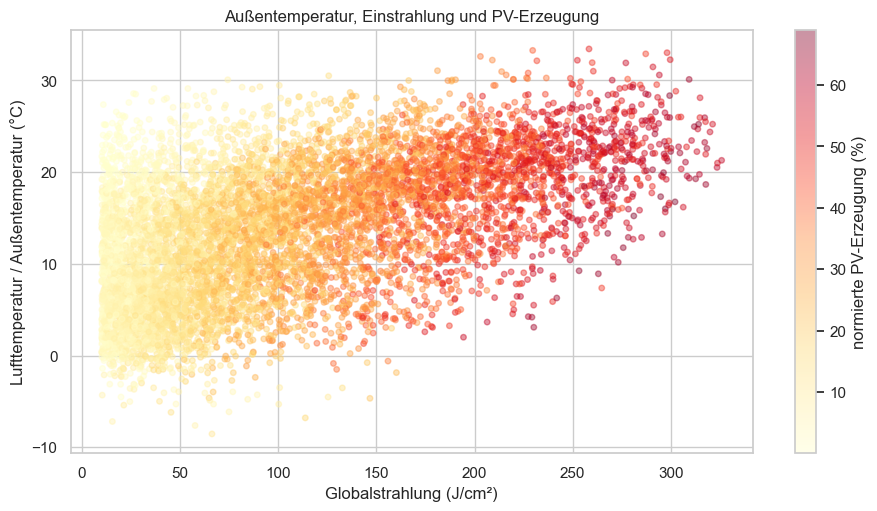

Gezeigt werden 24,184 PV-relevante Tageslichtstunden. Die lineare Korrelation zwischen Globalstrahlung und normierter Erzeugung beträgt 0.935.
Interpretation: Die dominante Zunahme mit der Einstrahlung kann einen schwächeren thermischen Effekt in der ungruppierten Punktwolke überdecken.


In [15]:
daylight = hourly[
    (hourly["global_radiation_j_cm2"] > 10)
    & (hourly["solar_zenith_angle_deg"] < 90)
    & hourly[TARGET].notna()
].copy()
sample = daylight.sample(min(8000, len(daylight)), random_state=42)

plt.figure(figsize=(11, 5.5))
scatter = plt.scatter(
    sample["global_radiation_j_cm2"],
    sample["temperature_c"],
    c=sample[TARGET] * 100,
    cmap="YlOrRd",
    s=16,
    alpha=.42,
)
plt.colorbar(scatter, label="normierte PV-Erzeugung (%)")
plt.xlabel("Globalstrahlung (J/cm²)")
plt.ylabel("Lufttemperatur / Außentemperatur (°C)")
plt.title("Außentemperatur, Einstrahlung und PV-Erzeugung")
plt.show()

print(
    f"Gezeigt werden {len(daylight):,} PV-relevante Tageslichtstunden. "
    f"Die lineare Korrelation zwischen Globalstrahlung und normierter Erzeugung "
    f"beträgt {daylight['global_radiation_j_cm2'].corr(daylight[TARGET]):.3f}."
)
print(
    "Interpretation: Die dominante Zunahme mit der Einstrahlung kann einen "
    "schwächeren thermischen Effekt in der ungruppierten Punktwolke überdecken."
)

## 5. Test der Temperaturthese bei starker Einstrahlung

Um Einstrahlung grob zu kontrollieren, werden nur Stunden im oberen
Strahlungsquartil verglichen. Saison, Sonnenstand und Wetter bleiben dennoch
mögliche Störfaktoren.

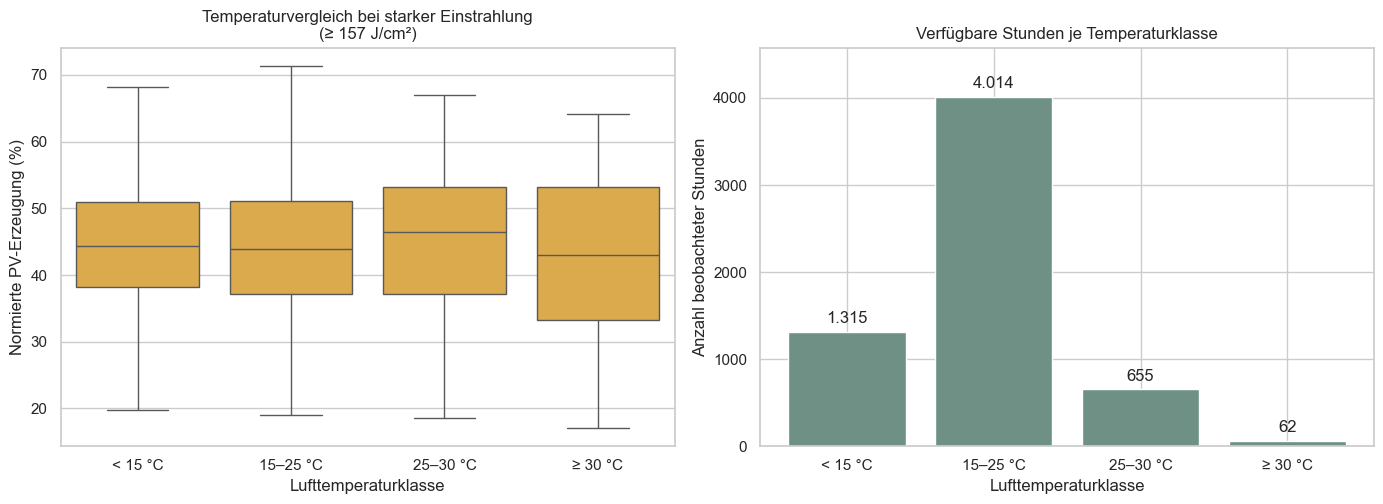

,Stunden,Mittelwert,Median
temperature_class,,,
< 15 °C,1315,44.69,44.29
15–25 °C,4014,44.00,43.83
25–30 °C,655,45.12,46.41
≥ 30 °C,62,42.64,43.00


Höchster beobachteter Median: 25–30 °C mit 46.41 %. Ab 30 °C liegt der Median um 3.40 Prozentpunkte darunter; diese Klasse umfasst 62 Stunden.
Einordnung zur These: Der niedrigere Median der heißesten Klasse ist mit der These vereinbar. Wegen der kleinen Gruppe und verbleibender Störfaktoren ist dies ein Hinweis, kein Kausalnachweis.


In [16]:
high_radiation_limit = daylight["global_radiation_j_cm2"].quantile(.75)
strong_sun = daylight[daylight["global_radiation_j_cm2"] >= high_radiation_limit].copy()
strong_sun["temperature_class"] = pd.cut(
    strong_sun["temperature_c"],
    [-30, 15, 25, 30, 60],
    labels=["< 15 °C", "15–25 °C", "25–30 °C", "≥ 30 °C"],
)
temperature_summary = strong_sun.groupby("temperature_class", observed=True)[TARGET].agg(
    Stunden="size", Mittelwert="mean", Median="median"
)
temperature_summary[["Mittelwert", "Median"]] *= 100
strong_sun["Normierte PV-Erzeugung (%)"] = strong_sun[TARGET] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
sns.boxplot(
    data=strong_sun.sample(min(8000, len(strong_sun)), random_state=42),
    x="temperature_class",
    y="Normierte PV-Erzeugung (%)",
    color="#F2B134",
    showfliers=False,
    ax=axes[0],
)
axes[0].set_xlabel("Lufttemperaturklasse")
axes[0].set_ylabel("Normierte PV-Erzeugung (%)")
axes[0].set_title(
    f"Temperaturvergleich bei starker Einstrahlung\n"
    f"(≥ {high_radiation_limit:.0f} J/cm²)"
)

count_bars = axes[1].bar(
    temperature_summary.index.astype(str),
    temperature_summary["Stunden"],
    color="#6F9185",
)
axes[1].bar_label(
    count_bars,
    labels=[f"{int(value):,}".replace(",", ".") for value in temperature_summary["Stunden"]],
    padding=4,
)
axes[1].set_xlabel("Lufttemperaturklasse")
axes[1].set_ylabel("Anzahl beobachteter Stunden")
axes[1].set_title("Verfügbare Stunden je Temperaturklasse")
axes[1].set_ylim(0, temperature_summary["Stunden"].max() * 1.14)
fig.tight_layout()
plt.show()

display(temperature_summary.round(2))

best_class = temperature_summary["Median"].idxmax()
best_median = temperature_summary.loc[best_class, "Median"]
hot_median = temperature_summary.loc["≥ 30 °C", "Median"]
hot_hours = int(temperature_summary.loc["≥ 30 °C", "Stunden"])
print(
    f"Höchster beobachteter Median: {best_class} mit {best_median:.2f} %. "
    f"Ab 30 °C liegt der Median um {best_median - hot_median:.2f} Prozentpunkte "
    f"darunter; diese Klasse umfasst {hot_hours} Stunden."
)
if hot_median < best_median:
    print(
        "Einordnung zur These: Der niedrigere Median der heißesten Klasse ist "
        "mit der These vereinbar. Wegen der kleinen Gruppe und verbleibender "
        "Störfaktoren ist dies ein Hinweis, kein Kausalnachweis."
    )
else:
    print(
        "Einordnung zur These: In dieser Gruppierung ist kein Rückgang der "
        "heißesten Klasse erkennbar. Die These wird damit nicht bestätigt, "
        "aber wegen möglicher Störfaktoren auch nicht abschließend widerlegt."
    )

## 6. Zeitlich ehrliches Prognosemodell

Der vollständige Stundenbestand bleibt für die Datenexploration erhalten. Für
das Modell werden daraus PV-relevante Tageslichtstunden mit Globalstrahlung
über 10 J/cm² und Sonnenzenit unter 90° ausgewählt. Die ersten 80 % dieser
Beobachtungen bilden das Training, die neuesten 20 % einen zusammenhängenden
Test. Das verhindert zufälliges Vermischen von Vergangenheit und Zukunft und
verhindert, dass leicht erkennbare Nachtstunden die Modellgüte dominieren.

Trainiert wird ein `HistGradientBoostingRegressor`. Das Modell bildet
nichtlineare Zusammenhänge ab, kann außerhalb beobachteter Merkmalsbereiche
aber keinen belastbaren Trend extrapolieren. Deshalb bleiben die App-Regler
innerhalb der Trainingsspannen.

Zentrale Einstellungen sind Lernrate 0,07, 190 Boosting-Iterationen, höchstens
31 Blätter pro Baum, mindestens 30 Beobachtungen pro Blatt,
L2-Regularisierung 1,0 und `random_state=42`. Die feste Zufallszahl macht
Permutationstests und wiederholte Trainings reproduzierbar.

### Tatsächliche Modellmerkmale

| Merkmal | Einheit | Herkunft |
|---|---:|---|
| Lufttemperatur | °C | DWD-Stationsmittel |
| Relative Luftfeuchtigkeit | % | DWD-Stationsmittel |
| Globalstrahlung | J/cm² | DWD-Stationsmittel |
| Bewölkung | Achtel | DWD-Stationsmittel |
| Windgeschwindigkeit | m/s | DWD-Stationsmittel |
| Geschätzte Modultemperatur | °C | aus Temperatur, Strahlung und Wind |
| Diffusanteil | Anteil | Diffusstrahlung / Globalstrahlung |

Uhrzeit, Monat und Sonnenstand dienen der Exploration beziehungsweise der
Auswahl von Tageslichtstunden, sind aber bewusst **keine Prognosemerkmale**.

### Physikalisch motivierte Richtungsannahmen

Ein Teil der Kurvenform wird durch Monotoniebedingungen stabilisiert:
Globalstrahlung und Wind dürfen bei ansonsten identischen Merkmalen nicht
senkend wirken; Temperatur, geschätzte Modultemperatur, Feuchte, Bewölkung und
Diffusanteil dürfen nicht steigernd wirken. Diese Annahmen verhindern
unplausibles Springen der Regler, bedeuten aber auch: Ein fallender
Temperaturverlauf ist nicht ausschließlich frei aus den Daten gelernt.

Die Kennzahlen entsprechen dem Bereich „Modellgüte“ in der Streamlit-App.
MAE und RMSE werden in Prozentpunkten angegeben; R² ist keine Trefferquote.
Die Zielvariable ist normierte PV-Erzeugung – ein „thermischer Verlust“ wird
nicht separat gemessen oder als eigene Zielgröße trainiert.

In [17]:
bundle = train_yield_model(data)
metrics = pd.DataFrame(
    {
        "Gradient Boosting": [
            bundle.metrics["model_mae"] * 100,
            bundle.metrics["model_rmse"] * 100,
            bundle.metrics["model_r2"],
        ],
        "Median-Baseline": [
            bundle.metrics["baseline_mae"] * 100,
            bundle.metrics["baseline_rmse"] * 100,
            bundle.metrics["baseline_r2"],
        ],
    },
    index=["MAE (Prozentpunkte)", "RMSE (Prozentpunkte)", "R²"],
)
print(f"Zeitlicher Test beginnt: {bundle.split_timestamp}")
print(
    f"Modellstunden: {int(bundle.metrics['model_rows']):,} von "
    f"{int(bundle.metrics['source_rows']):,} vollständigen Panelstunden"
)
display(metrics.round(3))

selection_summary = pd.Series(
    {
        "Vollständiges Stundenpanel": int(bundle.metrics["source_rows"]),
        "Ausgeschlossen: Nacht/Schwachlicht": int(
            bundle.metrics["excluded_low_light_rows"]
        ),
        "Ausgeschlossen: unvollständige Modellzeilen": int(
            bundle.metrics["excluded_incomplete_model_rows"]
        ),
        "Training": int(bundle.metrics["train_rows"]),
        "Zeitlicher Test": int(bundle.metrics["test_rows"]),
    },
    name="Stunden",
)
display(selection_summary.to_frame())

feature_names_de = {
    "temperature_c": ("Lufttemperatur", "°C"),
    "relative_humidity_pct": ("Relative Luftfeuchtigkeit", "%"),
    "global_radiation_j_cm2": ("Globalstrahlung", "J/cm²"),
    "cloud_cover_oktas": ("Bewölkung", "Achtel"),
    "wind_speed_m_s": ("Windgeschwindigkeit", "m/s"),
    "estimated_module_temperature_c": ("Geschätzte Modultemperatur", "°C"),
    "diffuse_share": ("Diffusanteil", "Anteil"),
}
direction_names = {-1: "darf isoliert nicht steigen", 0: "frei", 1: "darf isoliert nicht fallen"}
model_contract = pd.DataFrame(
    [
        {
            "Modellmerkmal": feature_names_de[feature][0],
            "Einheit": feature_names_de[feature][1],
            "Minimum Training": bundle.training_bounds[feature][0],
            "Maximum Training": bundle.training_bounds[feature][1],
            "Richtungsannahme": direction_names[MONOTONIC_CONSTRAINTS[feature]],
        }
        for feature in MODEL_FEATURES
    ]
)
display(model_contract.round(3))

improvement = 1 - bundle.metrics["model_mae"] / bundle.metrics["baseline_mae"]
print(
    f"Einordnung: Das Modell reduziert den mittleren absoluten Fehler gegenüber "
    f"der Median-Baseline um {improvement:.1%}. Prognosen werden technisch auf "
    f"0 bis 120 % begrenzt; beim normalen App-Szenario greift diese Grenze nicht."
)

Zeitlicher Test beginnt: 2024-09-22 16:00:00+00:00
Modellstunden: 24,183 von 52,608 vollständigen Panelstunden


,Gradient Boosting,Median-Baseline
MAE (Prozentpunkte),3.869,12.335
RMSE (Prozentpunkte),5.097,14.569
R²,0.878,-0.000


,Stunden
Vollständiges Stundenpanel,52608
Ausgeschlossen: Nacht/Schwachlicht,28424
Ausgeschlossen: unvollständige Modellzeilen,1
Training,19346
Zeitlicher Test,4837


,Modellmerkmal,Einheit,Minimum Training,Maximum Training,Richtungsannahme
0,Lufttemperatur,°C,-9.975,33.438,darf isoliert nicht steigen
1,Relative Luftfeuchtigkeit,%,25.467,97.562,darf isoliert nicht steigen
2,Globalstrahlung,J/cm²,10.062,325.562,darf isoliert nicht fallen
3,Bewölkung,Achtel,0.000,8.000,darf isoliert nicht steigen
4,Windgeschwindigkeit,m/s,1.238,13.356,darf isoliert nicht fallen
5,Geschätzte Modultemperatur,°C,-9.080,50.652,darf isoliert nicht steigen
6,Diffusanteil,Anteil,0.096,1.000,darf isoliert nicht steigen


Einordnung: Das Modell reduziert den mittleren absoluten Fehler gegenüber der Median-Baseline um 68.6%. Prognosen werden technisch auf 0 bis 120 % begrenzt; beim normalen App-Szenario greift diese Grenze nicht.


## 7. Prognose eines meteorologischen Szenarios

Dieses Referenzszenario verwendet dieselben Standardwerte wie die
Streamlit-App. Die installierte PV-Leistung skaliert nur die absolute Erzeugung;
die normierte Modellprognose bleibt unverändert.

### Eckdaten des Referenzszenarios

| Größe | Wert | Rolle |
|---|---:|---|
| Globalstrahlung | 270 J/cm² | direkte Modelleingabe |
| Lufttemperatur | 25 °C | direkte Modelleingabe |
| Bewölkung | 2/8 | direkte Modelleingabe |
| Windgeschwindigkeit | 3 m/s | direkte Modelleingabe |
| Relative Luftfeuchtigkeit | 55 % | direkte Modelleingabe |
| Installierte PV-Leistung | 90.000 MW | nur absolute Skalierung nach der Prognose |

Aus diesen Eckdaten entstehen zusätzlich ein Diffusanteil von 29 %, eine
angenäherte Diffusstrahlung von 78,3 J/cm², rund 38,2 Minuten
Sonnenscheindauer und eine geschätzte Modultemperatur von etwa 42,2 °C.
Sonnenscheindauer ist dabei kein Modellmerkmal. Ein Datum oder eine Uhrzeit
beeinflusst die Szenarioprognose ebenfalls nicht.

### Vertrag zwischen App und Modell

| Eingabe beziehungsweise Ableitung | Verarbeitung | Einfluss |
|---|---|---|
| Globalstrahlung, Temperatur, Bewölkung, Wind, Feuchte | direkt aus den Reglern | sichtbare meteorologische Eingaben |
| Diffusanteil | aus Bewölkung angenähert | zusätzliches Modellmerkmal |
| Geschätzte Modultemperatur | NOCT-artig aus Temperatur, Strahlung und Wind | zusätzliches Modellmerkmal |
| Sonnenscheindauer | für einen vollständigen Szenariodatensatz angenähert | derzeit kein Modellmerkmal |
| Uhrzeit, Monat, Sonnenstand | nicht verwendet | kein versteckter Szenarioeinfluss |
| Installierte Leistung | Prognose × MW | nur absolute Skalierung nach der Prognose |

Die Punktprognose ist der direkte Output des trainierten Modells. Das
empirische 80-%-Intervall entsteht anschließend aus dem 10-%- und
90-%-Quantil der Fehler im zeitlichen Test und verändert den Punktwert nicht.
Fehlende Modellmerkmale würden mit Trainingsmedianen ersetzt; das reguläre
App-Szenario liefert jedoch alle benötigten Merkmale.

In [18]:
def scenario_frame(
    radiation=270.0,
    temperature=25.0,
    cloud_cover=2.0,
    wind_speed=3.0,
    humidity=55.0,
):
    diffuse_share = np.clip(0.14 + 0.075 * cloud_cover, 0.12, 0.82)
    sunshine = np.clip(
        60 * (radiation / 330) * (1 - cloud_cover / 9),
        0,
        60,
    )
    return pd.DataFrame(
        {
            # Technischer Platzhalter: Kalenderwerte sind keine Modellmerkmale.
            "timestamp_utc": [pd.Timestamp("2024-01-01", tz="UTC")],
            "temperature_c": [temperature],
            "relative_humidity_pct": [humidity],
            "global_radiation_j_cm2": [radiation],
            "diffuse_radiation_j_cm2": [radiation * diffuse_share],
            "sunshine_duration_min": [sunshine],
            "cloud_cover_oktas": [cloud_cover],
            "wind_speed_m_s": [wind_speed],
        }
    )


current_scenario = scenario_frame()
current_prediction = predict_yield(bundle, current_scenario).iloc[0]
current_module_temperature = estimate_module_temperature(
    current_scenario["temperature_c"],
    current_scenario["global_radiation_j_cm2"],
    current_scenario["wind_speed_m_s"],
)[0]
installed_capacity_mw = 90_000

scenario_result = pd.DataFrame(
    {
        "Wert": [
            current_prediction["normalized_pv_prediction"] * 100,
            current_prediction["lower_80"] * 100,
            current_prediction["upper_80"] * 100,
            current_module_temperature,
            current_prediction["normalized_pv_prediction"]
            * installed_capacity_mw,
        ],
        "Einheit": [
            "%",
            "%",
            "%",
            "°C",
            "MW beziehungsweise MWh in einer Stunde",
        ],
    },
    index=[
        "Prognostizierte normierte PV-Erzeugung",
        "Untere Grenze des empirischen 80-%-Intervalls",
        "Obere Grenze des empirischen 80-%-Intervalls",
        "Geschätzte Modultemperatur",
        "Geschätzte Erzeugung bei 90.000 MW installierter Leistung",
    ],
)
display(scenario_result.round(2))

scenario_features = add_features(current_scenario)[MODEL_FEATURES].T
scenario_features.columns = ["Verwendeter Modellwert"]
display(scenario_features.round(3))
print(
    "Kontrollpunkt: Die installierte Leistung ist nicht Bestandteil dieser "
    "Merkmalsliste und beeinflusst daher nicht die normierte Prognose."
)

,Wert,Einheit
Prognostizierte normierte PV-Erzeugung,53.73,%
Untere Grenze des empirischen 80-%-Intervalls,45.42,%
Obere Grenze des empirischen 80-%-Intervalls,57.47,%
Geschätzte Modultemperatur,42.23,°C
Geschätzte Erzeugung bei 90.000 MW installierter Leistung,48353.15,MW beziehungsweise MWh in einer Stunde


,Verwendeter Modellwert
temperature_c,25.000
relative_humidity_pct,55.000
global_radiation_j_cm2,270.000
cloud_cover_oktas,2.000
wind_speed_m_s,3.000
estimated_module_temperature_c,42.233
diffuse_share,0.290


Kontrollpunkt: Die installierte Leistung ist nicht Bestandteil dieser Merkmalsliste und beeinflusst daher nicht die normierte Prognose.


## 8. Thermischer Effekt bei gleicher Einstrahlung

Die Lufttemperatur wird wie im App-Tab „Thermischer Effekt“ innerhalb ihres
beobachteten Trainingsbereichs variiert. Globalstrahlung, Bewölkung, Wind und
Luftfeuchtigkeit bleiben konstant. Kalender- und Uhrzeitwerte sind bewusst
keine Modellmerkmale. Die Kurve zeigt eine Modellreaktion und keinen isolierten
Kausalnachweis.

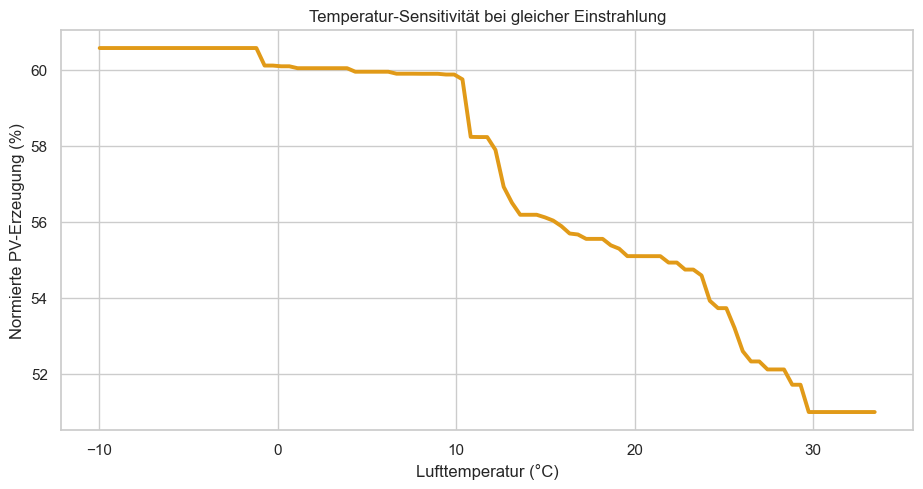

Über den beobachteten Trainingsbereich von -10.0 bis 33.4 °C verändert sich die Modellprognose bei ansonsten gleichen Eingaben um -9.59 Prozentpunkte.
Interpretation: Die Kurve ist eine kontrollierte Modellreaktion unter Monotoniebedingungen, kein experimenteller Nachweis eines thermischen Effekts.


In [19]:
temperature_min, temperature_max = bundle.training_bounds["temperature_c"]
temperatures = np.linspace(temperature_min, temperature_max, 95)
curve_input = pd.concat(
    [scenario_frame(temperature=float(value)) for value in temperatures],
    ignore_index=True,
)
curve_prediction = predict_yield(bundle, curve_input)
curve_data = pd.DataFrame(
    {
        "Lufttemperatur (°C)": temperatures,
        "Geschätzte Modultemperatur (°C)": estimate_module_temperature(
            temperatures,
            np.full_like(temperatures, 270.0),
            np.full_like(temperatures, 3.0),
        ),
        "Normierte PV-Erzeugung (%)": (
            curve_prediction["normalized_pv_prediction"].to_numpy() * 100
        ),
    }
)

plt.figure(figsize=(11, 5.2))
plt.plot(
    curve_data["Lufttemperatur (°C)"],
    curve_data["Normierte PV-Erzeugung (%)"],
    color="#E19A18",
    linewidth=2.8,
)
plt.xlabel("Lufttemperatur (°C)")
plt.ylabel("Normierte PV-Erzeugung (%)")
plt.title("Temperatur-Sensitivität bei gleicher Einstrahlung")
plt.show()

curve_change = (
    curve_data["Normierte PV-Erzeugung (%)"].iloc[-1]
    - curve_data["Normierte PV-Erzeugung (%)"].iloc[0]
)
print(
    f"Über den beobachteten Trainingsbereich von {temperature_min:.1f} bis "
    f"{temperature_max:.1f} °C verändert sich die Modellprognose bei ansonsten "
    f"gleichen Eingaben um {curve_change:+.2f} Prozentpunkte."
)
print(
    "Interpretation: Die Kurve ist eine kontrollierte Modellreaktion unter "
    "Monotoniebedingungen, kein experimenteller Nachweis eines thermischen Effekts."
)

## 9. Aktuelles Szenario und Top-2-%-Bedingungen

„Optimal“ bezeichnet die Medianbedingungen der besten 2 % beobachteten Stunden.
Das ist ein beobachtungsnaher Vergleich und kein technisch garantiertes
Anlagenoptimum. Zu unterscheiden sind:

1. die tatsächlich beobachtete Erzeugung der besten 2 % Stunden,
2. der Median ihrer einzelnen Wetterbedingungen und
3. die Modellprognose für das daraus zusammengesetzte Szenario.

Die Medianbedingungen müssen nicht gemeinsam in genau einer realen Stunde
aufgetreten sein.

,Normierte PV-Erzeugung (%)
Aktuelles Szenario,53.73
Top-2-%-Bedingungen,52.71
Differenz zu den Top-2-%-Bedingungen,1.01


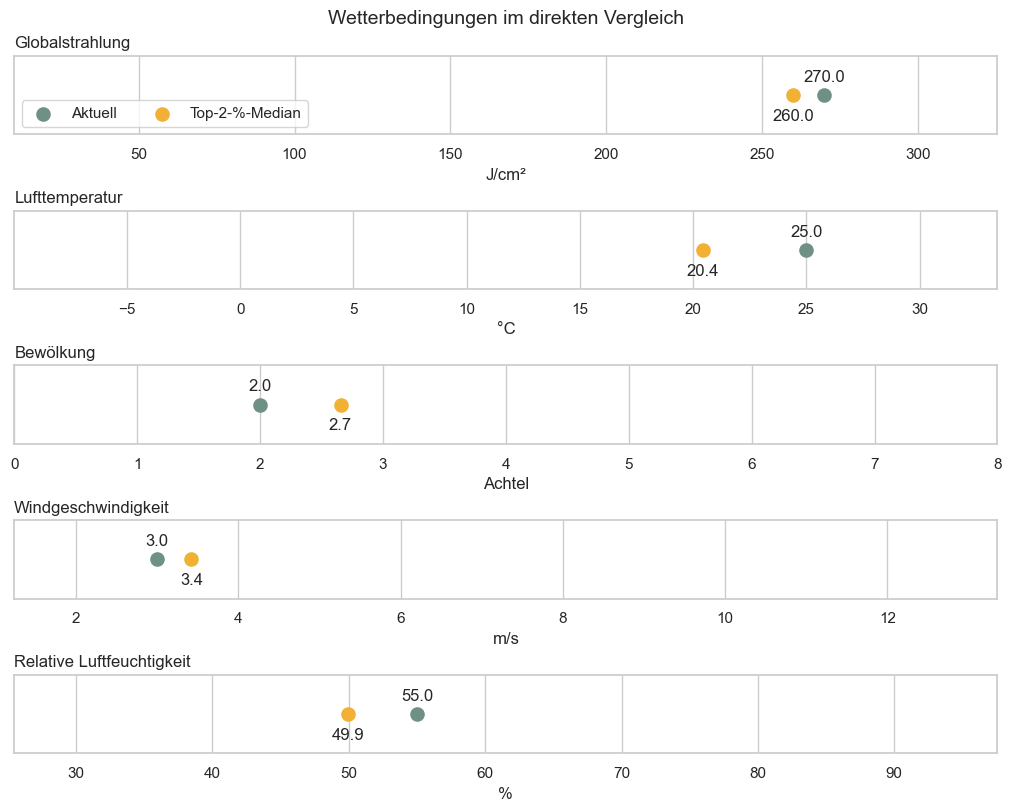

Median der tatsächlich beobachteten Top-2-%-Erzeugung: 57.70 %. Modellprognose für die zusammengesetzten Medianbedingungen: 52.71 %.
Die Differenz ist erwartbar, weil ein aus Einzelmedianen zusammengesetztes Szenario keine konkrete beobachtete Stunde sein muss.


In [20]:
top = hourly.nlargest(max(50, int(len(hourly) * .02)), TARGET)
optimal_defaults = {
    column: float(top[column].median())
    for column in [
        "temperature_c",
        "relative_humidity_pct",
        "global_radiation_j_cm2",
        "cloud_cover_oktas",
        "wind_speed_m_s",
    ]
}
optimal_scenario = scenario_frame(
    radiation=optimal_defaults["global_radiation_j_cm2"],
    temperature=optimal_defaults["temperature_c"],
    cloud_cover=optimal_defaults["cloud_cover_oktas"],
    wind_speed=optimal_defaults["wind_speed_m_s"],
    humidity=optimal_defaults["relative_humidity_pct"],
)
optimal_prediction = predict_yield(bundle, optimal_scenario).iloc[0]

yield_comparison = pd.DataFrame(
    {
        "Normierte PV-Erzeugung (%)": [
            current_prediction["normalized_pv_prediction"] * 100,
            optimal_prediction["normalized_pv_prediction"] * 100,
            (
                current_prediction["normalized_pv_prediction"]
                - optimal_prediction["normalized_pv_prediction"]
            )
            * 100,
        ]
    },
    index=[
        "Aktuelles Szenario",
        "Top-2-%-Bedingungen",
        "Differenz zu den Top-2-%-Bedingungen",
    ],
)
display(yield_comparison.round(2))

condition_specs = [
    (
        "Globalstrahlung", "J/cm²",
        *bundle.training_bounds["global_radiation_j_cm2"],
        270.0, optimal_defaults["global_radiation_j_cm2"],
    ),
    (
        "Lufttemperatur", "°C",
        *bundle.training_bounds["temperature_c"],
        25.0, optimal_defaults["temperature_c"],
    ),
    (
        "Bewölkung", "Achtel",
        *bundle.training_bounds["cloud_cover_oktas"],
        2.0, optimal_defaults["cloud_cover_oktas"],
    ),
    (
        "Windgeschwindigkeit", "m/s",
        *bundle.training_bounds["wind_speed_m_s"],
        3.0, optimal_defaults["wind_speed_m_s"],
    ),
    (
        "Relative Luftfeuchtigkeit", "%",
        *bundle.training_bounds["relative_humidity_pct"],
        55.0, optimal_defaults["relative_humidity_pct"],
    ),
]
fig, axes = plt.subplots(len(condition_specs), 1, figsize=(10, 8), constrained_layout=True)
for index, (label, unit, minimum, maximum, current_value, optimal_value) in enumerate(
    condition_specs
):
    axis = axes[index]
    axis.scatter(current_value, 0, s=90, color="#6F9185", label="Aktuell")
    axis.scatter(optimal_value, 0, s=90, color="#F2B134", label="Top-2-%-Median")
    axis.set_xlim(minimum, maximum)
    axis.set_yticks([])
    axis.set_xlabel(unit)
    axis.set_title(label, loc="left")
    axis.annotate(
        f"{current_value:.1f}",
        (current_value, 0),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
    )
    axis.annotate(
        f"{optimal_value:.1f}",
        (optimal_value, 0),
        xytext=(0, -18),
        textcoords="offset points",
        ha="center",
    )
axes[0].legend(loc="lower left", ncol=2)
fig.suptitle("Wetterbedingungen im direkten Vergleich", fontsize=14)
plt.show()

observed_top_median = top[TARGET].median() * 100
print(
    f"Median der tatsächlich beobachteten Top-2-%-Erzeugung: "
    f"{observed_top_median:.2f} %. Modellprognose für die zusammengesetzten "
    f"Medianbedingungen: "
    f"{optimal_prediction['normalized_pv_prediction'] * 100:.2f} %."
)
print(
    "Die Differenz ist erwartbar, weil ein aus Einzelmedianen zusammengesetztes "
    "Szenario keine konkrete beobachtete Stunde sein muss."
)

## 10. Implementierungslandkarte

Die Streamlit-App und dieses Notebook verwenden dieselbe Kernlogik. Dadurch
werden Zielvariable, Feature Engineering, Trainingsfilter und Prognose nicht
zweimal unabhängig implementiert.

| Datei | Verantwortung |
|---|---|
| `app.py` | Navigation, Regler, Diagramme und erklärende Oberfläche |
| `pv_weather/data.py` | Schema, Validierung, Laden und Demo-Fallback |
| `pv_weather/download.py` | automatischer Bezug der SMARD-/DWD-Rohdaten |
| `pv_weather/ingest.py` | Einlesen, Stundenaggregation und Stationsmittel |
| `pv_weather/features.py` | Zielvariable und abgeleitete Merkmale |
| `pv_weather/modeling.py` | Tageslichtfilter, Training, Test und Prognose |
| `pv_weather/workflow.py` | atomarer Download-Aufbereitungs-Trainingsablauf |
| `scripts/create_notebook.py` | Generator dieser ausführbaren Dokumentation |
| `tests/` | automatisierte Verträge für Daten, Modell und Workflow |

### App-Tabs

- **Prognose:** direkte Modellprognose, Testresiduen-Intervall und absolute
  Skalierung
- **Thermischer Effekt:** Temperaturvariation bei konstanten übrigen
  Szenarioeingaben
- **Optimale Bedingungen:** Vergleich mit Medianbedingungen der besten 2 %
- **Datenexploration:** beobachtete Zusammenhänge und Temperaturklassen
- **Über die App:** Modellgüte, Realdaten-Workflow, Grenzen und Datenausschnitt

## 11. Reproduzierbarkeit und Aktualisierung

Alle Befehle werden im Projektverzeichnis ausgeführt:

```powershell
# Abhängigkeiten installieren
python -m venv .venv
.venv\Scripts\Activate.ps1
python -m pip install -r requirements.txt

# Realdaten laden, Panel erzeugen und Test-Training ausführen
python scripts/download_real_data.py --start-year 2020 --end-year 2025

# Diese Dokumentation neu erzeugen und vollständig ausführen
python scripts/create_notebook.py --execute

# Automatisierte Prüfungen
python -m pytest

# App starten
streamlit run app.py
```

Alternativ kann der Download einschließlich Training unter **Über die App**
gestartet werden. Der bisherige Datensatz wird dabei erst ersetzt, wenn
Aufbereitung und Test-Training erfolgreich abgeschlossen wurden.

**Wichtiger Hinweis:** `scripts/create_notebook.py --execute` erzeugt die
Notebookdatei vollständig neu. Manuelle Änderungen direkt in der `.ipynb`
werden beim nächsten Lauf überschrieben und gehören deshalb in den Generator.

Für eine reproduzierbare Abgabe sollten folgende Artefakte gemeinsam geprüft
werden:

- `data/raw/download_manifest.json`
- `data/processed/hourly_pv_weather.csv`
- `notebooks/pv_wetter_deutschland.ipynb`
- Ausgabe von `python -m pytest`
- Quellenangabe „Bundesnetzagentur | SMARD.de“ gemäß CC BY 4.0

Die Nutzung generativer KI als Entwicklungswerkzeug ist zusätzlich in
`KI_NUTZUNG.md` dokumentiert.

## 12. Fazit, Aussage zur These und Grenzen

Die Forschungsfrage wird über das Zusammenspiel von Einstrahlung,
Außentemperatur, geschätzter Modultemperatur und normierter PV-Erzeugung
beantwortet. Entscheidend ist der Temperaturvergleich bei ähnlicher
Einstrahlung: Eine über alle Strahlungsstärken gemischte Punktwolke kann den
thermischen Effekt durch den dominanten positiven Strahlungseffekt verdecken.

Eine empirische Schlussfolgerung ist nur zulässig, wenn oben Realdaten
ausgewiesen sind.

### Aussage zur These

Der Temperaturvergleich bei starker Einstrahlung liefert einen deskriptiven
Hinweis darauf, ob besonders heiße Stunden niedrigere normierte Erzeugung
aufweisen. Die konkrete Gruppentabelle und die Zahl verfügbarer heißer Stunden
sind dabei gemeinsam zu lesen. Ein Unterschied der Gruppenmediane unterstützt
die These nur vorläufig; er beweist keinen kausalen thermischen Verlust.

### Wichtige Grenzen

- Das ungewichtete Stationsmittel approximiert das Wetter der räumlich
  verteilten PV-Flotte. Regionen mit vielen Stationen zählen stärker, regionale
  PV-Leistungsunterschiede bleiben unberücksichtigt und fehlende Stationswerte
  können die Zusammensetzung des Mittels verändern.
- Jährliche Kapazitätswerte bilden unterjährigen Ausbau nicht ab.
- Die Modultemperatur wird nicht gemessen, sondern aus Lufttemperatur,
  horizontaler Globalstrahlung und Wind angenähert.
- Die Monotoniebedingungen beeinflussen die Richtung der Modellreaktionen und
  sind nicht ausschließlich aus den Daten gelernt.
- Prognosen werden nur innerhalb der beobachteten Trainingsspannen angeboten;
  das baumbasierte Modell liefert keine belastbare physikalische Extrapolation.
- Besonders heiße Stunden sind selten. Aussagen zu hohen Temperaturen besitzen
  daher eine deutlich kleinere Datenbasis.
- SMARD- und DWD-Stunden können unterschiedliche Intervallbezüge besitzen; ein
  möglicher Zeitversatz muss vor einer kausalen Interpretation separat geprüft
  werden.
- Je Wettergröße können unterschiedlich viele Stationen verfügbar sein, sodass
  sich die Zusammensetzung des Deutschlandmittels verändern kann.
- Anlagenneigung, Ausrichtung, Schnee, Verschattung, Abregelung und technische
  Verfügbarkeit fehlen.
- Gruppenvergleiche und Modellreaktionen sind keine Kausalnachweise.

### Dokumentationsfazit

Das Notebook verbindet damit fachliche Argumentation und technische
Nachvollziehbarkeit: Es dokumentiert Datenherkunft, Qualität, Transformationen,
Trainingsvertrag, App-Szenarien, Ergebnisse, Reproduktion und Grenzen in einem
ausführbaren Artefakt.